<a href="https://colab.research.google.com/github/mayank454eng/AIML/blob/main/Copy_of_Sentimental_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import gradio as gr
import nltk
nltk.download('maxent_ne_chunker_tab')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('words')
nltk.download('vader_lexicon')
from nltk import word_tokenize , pos_tag
import matplotlib.pyplot as plt
plt.style.use('ggplot')


In [ ]:
df = pd.read_csv('reviews.csv')
print(df.shape)
df = df.head(1000)
print(df.shape)

(12495, 12)
(1000, 12)


In [ ]:
df.head(10)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId
0,gp:AOqpTOEhZuqSqqWnaKRgv-9ABYdajFUB0WugPGh-SG-...,Eric Tie,https://play-lh.googleusercontent.com/a-/AOh14...,I cannot open the app anymore,1,0,5.4.0.6,2020-10-27 21:24:41,NaN,NaN,newest,com.anydo
1,gp:AOqpTOH0WP4IQKBZ2LrdNmFy_YmpPCVrV3diEU9KGm3...,john alpha,https://play-lh.googleusercontent.com/a-/AOh14...,I have been begging for a refund from this app...,1,0,NaN,2020-10-27 14:03:28,"Please note that from checking our records, yo...",2020-10-27 15:05:52,newest,com.anydo
2,gp:AOqpTOEMCkJB8Iq1p-r9dPwnSYadA5BkPWTf32Z1azu...,Sudhakar .S,https://play-lh.googleusercontent.com/a-/AOh14...,Very costly for the premium version (approx In...,1,0,NaN,2020-10-27 08:18:40,NaN,NaN,newest,com.anydo
3,gp:AOqpTOGFrUWuKGycpje8kszj3uwHN6tU_fd4gLVFy9z...,SKGflorida@bellsouth.net DAVID S,https://play-lh.googleusercontent.com/-75aK0WF...,"Used to keep me organized, but all the 2020 UP...",1,0,NaN,2020-10-26 13:28:07,What do you find troublesome about the update?...,2020-10-26 14:58:29,newest,com.anydo
4,gp:AOqpTOHls7DW8wmDFzTkHwxuqFkdNQtKHmO6Pt9jhZE...,Louann Stoker,https://play-lh.googleusercontent.com/-pBcY_Z-...,Dan Birthday Oct 28,1,0,5.6.0.7,2020-10-26 06:10:50,NaN,NaN,newest,com.anydo
5,gp:AOqpTOEvElPsBa6k8rLDmk-WrEoJea98KUrIGYWodJe...,Jon Clemens,https://play-lh.googleusercontent.com/-q6L1fx0...,It has changed how I viewed my different lists...,1,1,5.6.0.7,2020-10-26 05:04:20,Please note that in order to sort the lists by...,2020-10-26 14:56:25,newest,com.anydo
6,gp:AOqpTOGHb-APKKMNFyL1OwuGq1AGW6bQp5aYYxSHvJx...,Gale W,https://play-lh.googleusercontent.com/a-/AOh14...,I'm only looking for a grocery list app but ev...,1,0,5.6.0.6,2020-10-25 23:40:46,Sorry about that. We are not aware of any issu...,2020-10-26 14:53:42,newest,com.anydo
7,gp:AOqpTOEcxvv_c0CK3G5tHjxXsGSjbzD65OQ3og02p-q...,No One,https://play-lh.googleusercontent.com/a-/AOh14...,"Reset my free trial, new phone I'd like to see...",1,0,5.5.0.8,2020-10-25 19:18:13,We have an extensive Help Center detailing how...,2020-10-26 14:43:36,newest,com.anydo
8,gp:AOqpTOHVgr7_qOhORsfPwnVCqX-n98dJ1Ksrps6q52p...,I Dewa Gede Nopi Ariana,https://play-lh.googleusercontent.com/a-/AOh14...,How do to stop monthly payment because i don't...,1,0,5.6.0.7,2020-10-25 10:09:00,Please note that you may cancel your subscript...,2020-10-26 14:39:59,newest,com.anydo
9,gp:AOqpTOHQ_paQ_ffWsMqGOWmMsPxs-pBkBgR_3H63WJv...,John Riddle,https://play-lh.googleusercontent.com/a-/AOh14...,I complain about not crashes and it was immedi...,1,1,5.6.0.7,2020-10-23 03:15:01,We are unaware of any issues with the app not ...,2020-10-25 17:11:06,newest,com.anydo


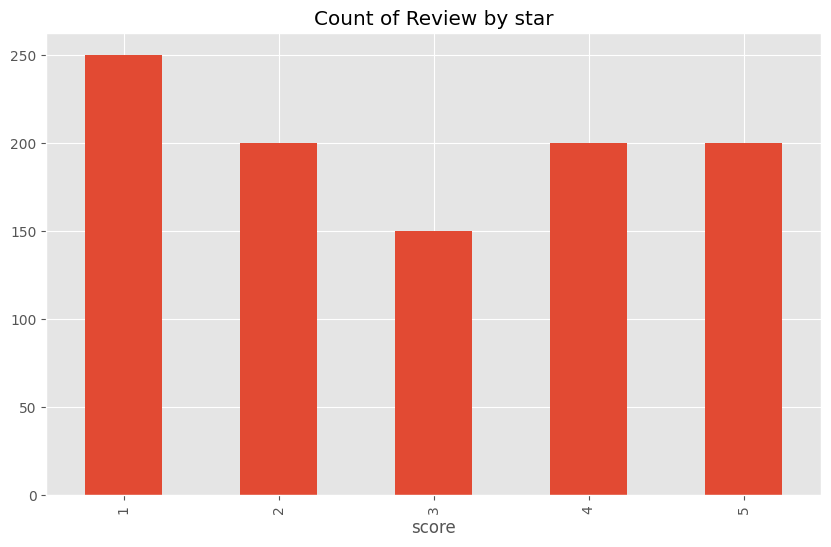

In [ ]:
ax = df['score'].value_counts().sort_index()\
  .plot(kind='bar',
        title='Count of Review by star',
        figsize=(10,6))
plt.show()

In [ ]:
example = df['content'][56]
print(example)

They recently started sending spammy notifications every week or so. Please stop.


In [ ]:
tokens = nltk.word_tokenize(example)
tokens[:10]

['They',
 'recently',
 'started',
 'sending',
 'spammy',
 'notifications',
 'every',
 'week',
 'or',
 'so']

In [ ]:
tagged = nltk.pos_tag(tokens)
tagged[:10]

[('They', 'PRP'),
 ('recently', 'RB'),
 ('started', 'VBD'),
 ('sending', 'VBG'),
 ('spammy', 'NN'),
 ('notifications', 'NNS'),
 ('every', 'DT'),
 ('week', 'NN'),
 ('or', 'CC'),
 ('so', 'RB')]

In [ ]:
entities = nltk.chunk.ne_chunk(tagged)
entities.pprint()

(S
  They/PRP
  recently/RB
  started/VBD
  sending/VBG
  spammy/NN
  notifications/NNS
  every/DT
  week/NN
  or/CC
  so/RB
  ./.
  Please/NNP
  stop/NN
  ./.)


In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm
sia = SentimentIntensityAnalyzer()

### Recalculate sentiment scores for the expanded DataFrame

Since `df` now contains 1000 rows, we need to re-calculate the sentiment scores for all these reviews before merging them into `vaders`.

In [ ]:
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['content']
    res[i] = sia.polarity_scores(text)

  0%|          | 0/1000 [00:00<?, ?it/s]

### Recreate the `vaders` DataFrame

Now that `res` is updated, we can recreate the `vaders` DataFrame by merging the new sentiment scores with the `df`.

In [ ]:
vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={'index': 'Id'})
vaders = vaders.merge(df, left_on='Id', right_index=True, how='left')
display(vaders.head())

,Id,neg,neu,pos,compound,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId
0,0,0.000,1.000,0.000,0.0000,gp:AOqpTOEhZuqSqqWnaKRgv-9ABYdajFUB0WugPGh-SG-...,Eric Tie,https://play-lh.googleusercontent.com/a-/AOh14...,I cannot open the app anymore,1,0,5.4.0.6,2020-10-27 21:24:41,NaN,NaN,newest,com.anydo
1,1,0.000,1.000,0.000,0.0000,gp:AOqpTOH0WP4IQKBZ2LrdNmFy_YmpPCVrV3diEU9KGm3...,john alpha,https://play-lh.googleusercontent.com/a-/AOh14...,I have been begging for a refund from this app...,1,0,NaN,2020-10-27 14:03:28,"Please note that from checking our records, yo...",2020-10-27 15:05:52,newest,com.anydo
2,2,0.042,0.809,0.149,0.6597,gp:AOqpTOEMCkJB8Iq1p-r9dPwnSYadA5BkPWTf32Z1azu...,Sudhakar .S,https://play-lh.googleusercontent.com/a-/AOh14...,Very costly for the premium version (approx In...,1,0,NaN,2020-10-27 08:18:40,NaN,NaN,newest,com.anydo
3,3,0.202,0.772,0.026,-0.8576,gp:AOqpTOGFrUWuKGycpje8kszj3uwHN6tU_fd4gLVFy9z...,SKGflorida@bellsouth.net DAVID S,https://play-lh.googleusercontent.com/-75aK0WF...,"Used to keep me organized, but all the 2020 UP...",1,0,NaN,2020-10-26 13:28:07,What do you find troublesome about the update?...,2020-10-26 14:58:29,newest,com.anydo
4,4,0.000,1.000,0.000,0.0000,gp:AOqpTOHls7DW8wmDFzTkHwxuqFkdNQtKHmO6Pt9jhZE...,Louann Stoker,https://play-lh.googleusercontent.com/-pBcY_Z-...,Dan Birthday Oct 28,1,0,5.6.0.7,2020-10-26 06:10:50,NaN,NaN,newest,com.anydo


In [ ]:
sia.polarity_scores('I am so happy ')

{'neg': 0.0, 'neu': 0.334, 'pos': 0.666, 'compound': 0.6115}

In [ ]:
sia.polarity_scores('This is the worst thing ever')

{'neg': 0.451, 'neu': 0.549, 'pos': 0.0, 'compound': -0.6249}

In [ ]:
sia.polarity_scores(example)

{'neg': 0.16, 'neu': 0.646, 'pos': 0.193, 'compound': 0.1313}

In [ ]:
vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={'index': 'Id'})
vaders = vaders.merge(df, left_on='Id', right_index=True, how='left')

In [ ]:
vaders.head(50)

,Id,neg,neu,pos,compound,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId
0,0,0.000,1.000,0.000,0.0000,gp:AOqpTOEhZuqSqqWnaKRgv-9ABYdajFUB0WugPGh-SG-...,Eric Tie,https://play-lh.googleusercontent.com/a-/AOh14...,I cannot open the app anymore,1,0,5.4.0.6,2020-10-27 21:24:41,NaN,NaN,newest,com.anydo
1,1,0.000,1.000,0.000,0.0000,gp:AOqpTOH0WP4IQKBZ2LrdNmFy_YmpPCVrV3diEU9KGm3...,john alpha,https://play-lh.googleusercontent.com/a-/AOh14...,I have been begging for a refund from this app...,1,0,NaN,2020-10-27 14:03:28,"Please note that from checking our records, yo...",2020-10-27 15:05:52,newest,com.anydo
2,2,0.042,0.809,0.149,0.6597,gp:AOqpTOEMCkJB8Iq1p-r9dPwnSYadA5BkPWTf32Z1azu...,Sudhakar .S,https://play-lh.googleusercontent.com/a-/AOh14...,Very costly for the premium version (approx In...,1,0,NaN,2020-10-27 08:18:40,NaN,NaN,newest,com.anydo
3,3,0.202,0.772,0.026,-0.8576,gp:AOqpTOGFrUWuKGycpje8kszj3uwHN6tU_fd4gLVFy9z...,SKGflorida@bellsouth.net DAVID S,https://play-lh.googleusercontent.com/-75aK0WF...,"Used to keep me organized, but all the 2020 UP...",1,0,NaN,2020-10-26 13:28:07,What do you find troublesome about the update?...,2020-10-26 14:58:29,newest,com.anydo
4,4,0.000,1.000,0.000,0.0000,gp:AOqpTOHls7DW8wmDFzTkHwxuqFkdNQtKHmO6Pt9jhZE...,Louann Stoker,https://play-lh.googleusercontent.com/-pBcY_Z-...,Dan Birthday Oct 28,1,0,5.6.0.7,2020-10-26 06:10:50,NaN,NaN,newest,com.anydo
5,5,0.000,1.000,0.000,0.0000,gp:AOqpTOEvElPsBa6k8rLDmk-WrEoJea98KUrIGYWodJe...,Jon Clemens,https://play-lh.googleusercontent.com/-q6L1fx0...,It has changed how I viewed my different lists...,1,1,5.6.0.7,2020-10-26 05:04:20,Please note that in order to sort the lists by...,2020-10-26 14:56:25,newest,com.anydo
6,6,0.028,0.944,0.028,-0.0039,gp:AOqpTOGHb-APKKMNFyL1OwuGq1AGW6bQp5aYYxSHvJx...,Gale W,https://play-lh.googleusercontent.com/a-/AOh14...,I'm only looking for a grocery list app but ev...,1,0,5.6.0.6,2020-10-25 23:40:46,Sorry about that. We are not aware of any issu...,2020-10-26 14:53:42,newest,com.anydo
7,7,0.000,0.535,0.465,0.8271,gp:AOqpTOEcxvv_c0CK3G5tHjxXsGSjbzD65OQ3og02p-q...,No One,https://play-lh.googleusercontent.com/a-/AOh14...,"Reset my free trial, new phone I'd like to see...",1,0,5.5.0.8,2020-10-25 19:18:13,We have an extensive Help Center detailing how...,2020-10-26 14:43:36,newest,com.anydo
8,8,0.167,0.833,0.000,-0.2960,gp:AOqpTOHVgr7_qOhORsfPwnVCqX-n98dJ1Ksrps6q52p...,I Dewa Gede Nopi Ariana,https://play-lh.googleusercontent.com/a-/AOh14...,How do to stop monthly payment because i don't...,1,0,5.6.0.7,2020-10-25 10:09:00,Please note that you may cancel your subscript...,2020-10-26 14:39:59,newest,com.anydo
9,9,0.043,0.957,0.000,-0.4438,gp:AOqpTOHQ_paQ_ffWsMqGOWmMsPxs-pBkBgR_3H63WJv...,John Riddle,https://play-lh.googleusercontent.com/a-/AOh14...,I complain about not crashes and it was immedi...,1,1,5.6.0.7,2020-10-23 03:15:01,We are unaware of any issues with the app not ...,2020-10-25 17:11:06,newest,com.anydo


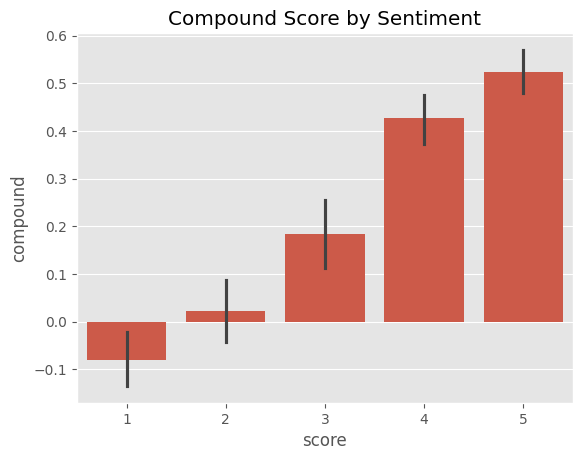

In [ ]:
ax= sns.barplot(data = vaders, x='score' , y='compound')
ax.set_title('Compound Score by Sentiment')
plt.show(5)

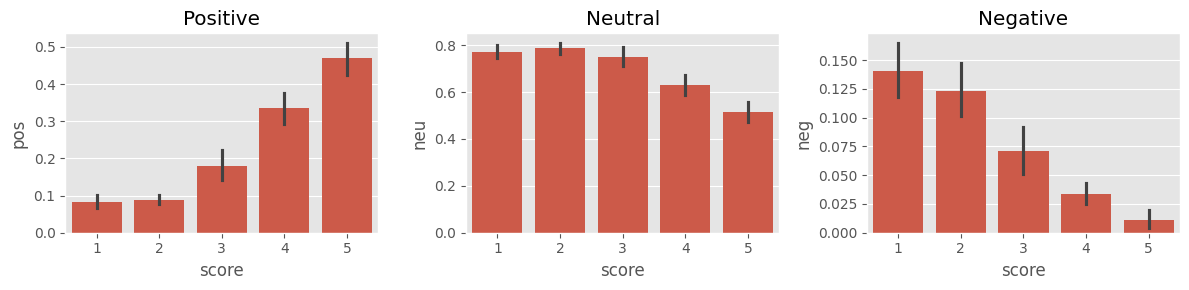

In [ ]:
fig,axs = plt.subplots(1,3,figsize=(12,3))
sns.barplot(data=vaders,x='score',y='pos',ax=axs[0])
sns.barplot(data=vaders,x='score',y='neu',ax=axs[1])
sns.barplot(data=vaders,x='score',y='neg',ax=axs[2])
axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')
plt.tight_layout()
plt.show()

In [ ]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

In [ ]:
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
print(example)
sia.polarity_scores(example)

They recently started sending spammy notifications every week or so. Please stop.


{'neg': 0.16, 'neu': 0.646, 'pos': 0.193, 'compound': 0.1313}

In [ ]:
def polarity_scores_roberta(example):
    encoded_text = tokenizer(example, return_tensors='pt')
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    scores_dict = {
        'roberta_neg' : scores[0],
        'roberta_neu' : scores[1],
        'roberta_pos' : scores[2]
    }
    return scores_dict

In [ ]:
for i, row in tqdm(df.iterrows(), total=len(df)):
    try:
        text = row['content'] # Changed 'Text' to 'content'
        myid = row['reviewId'] # Changed 'Id' to 'reviewId'
        vader_result = sia.polarity_scores(text)
        vader_result_rename = {}
        for key, value in vader_result.items():
            vader_result_rename[f"vader_{key}"] = value
        roberta_result = polarity_scores_roberta(text)
        both = {**vader_result_rename, **roberta_result}
        res[myid] = both
    except RuntimeError:
        print(f'Broke for id {myid}')

  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
all_user_scores_list = []
input_counter = 0

while True:
    user_input_text = input("Enter text for sentiment analysis (type 'done' to finish): ")
    if user_input_text.lower() == 'done':
        break
    if not user_input_text.strip():
        print("Empty input, please try again.")
        continue

    input_counter += 1
    vader_user_result = sia.polarity_scores(user_input_text)
    vader_user_rename = {}
    for key, value in vader_user_result.items():
        vader_user_rename[f"vader_{key}"] = value

    roberta_user_result = polarity_scores_roberta(user_input_text)
    combined_scores = {
        "Input_ID": f"Input {input_counter}",
        "Original_Text": user_input_text,
        **vader_user_rename,
        **roberta_user_result
    }
    all_user_scores_list.append(combined_scores)

    print(f"\n--- Analysis for: '{user_input_text}' ---")
    print("VADER Scores:")
    for k, v in vader_user_rename.items():
        print(f"  {k}: {v:.4f}")
    print("RoBERTa Scores:")
    for k, v in roberta_user_result.items():
        print(f"  {k}: {v:.4f}")
    print("-" * 30)

if not all_user_scores_list:
    print("No input provided for analysis.")
else:
    print(f"Collected {len(all_user_scores_list)} inputs for analysis.")

In [ ]:
if 'all_user_scores_list' in globals() and all_user_scores_list:
    user_scores_df = pd.DataFrame(all_user_scores_list)
    print("DataFrame for User Input Sentiment Scores:")
    display(user_scores_df)
else:
    print("No sentiment data collected from user input to create a DataFrame.")
    user_scores_df = pd.DataFrame()

DataFrame for User Input Sentiment Scores:


,Input_ID,Original_Text,vader_neg,vader_neu,vader_pos,vader_compound,roberta_neg,roberta_neu,roberta_pos
0,Input 1,I love yashi,0.000,0.192,0.808,0.6369,0.003201,0.027348,0.969451
1,Input 2,I hate my self,0.649,0.351,0.000,-0.5719,0.949462,0.042072,0.008466
2,Input 3,I got fat,0.000,1.000,0.000,0.0000,0.730940,0.239406,0.029653
3,Input 4,it was so good,0.000,0.445,0.555,0.5777,0.004063,0.016218,0.979720
4,Input 5,Fuck that was shit,0.780,0.220,0.000,-0.7964,0.946011,0.043028,0.010961


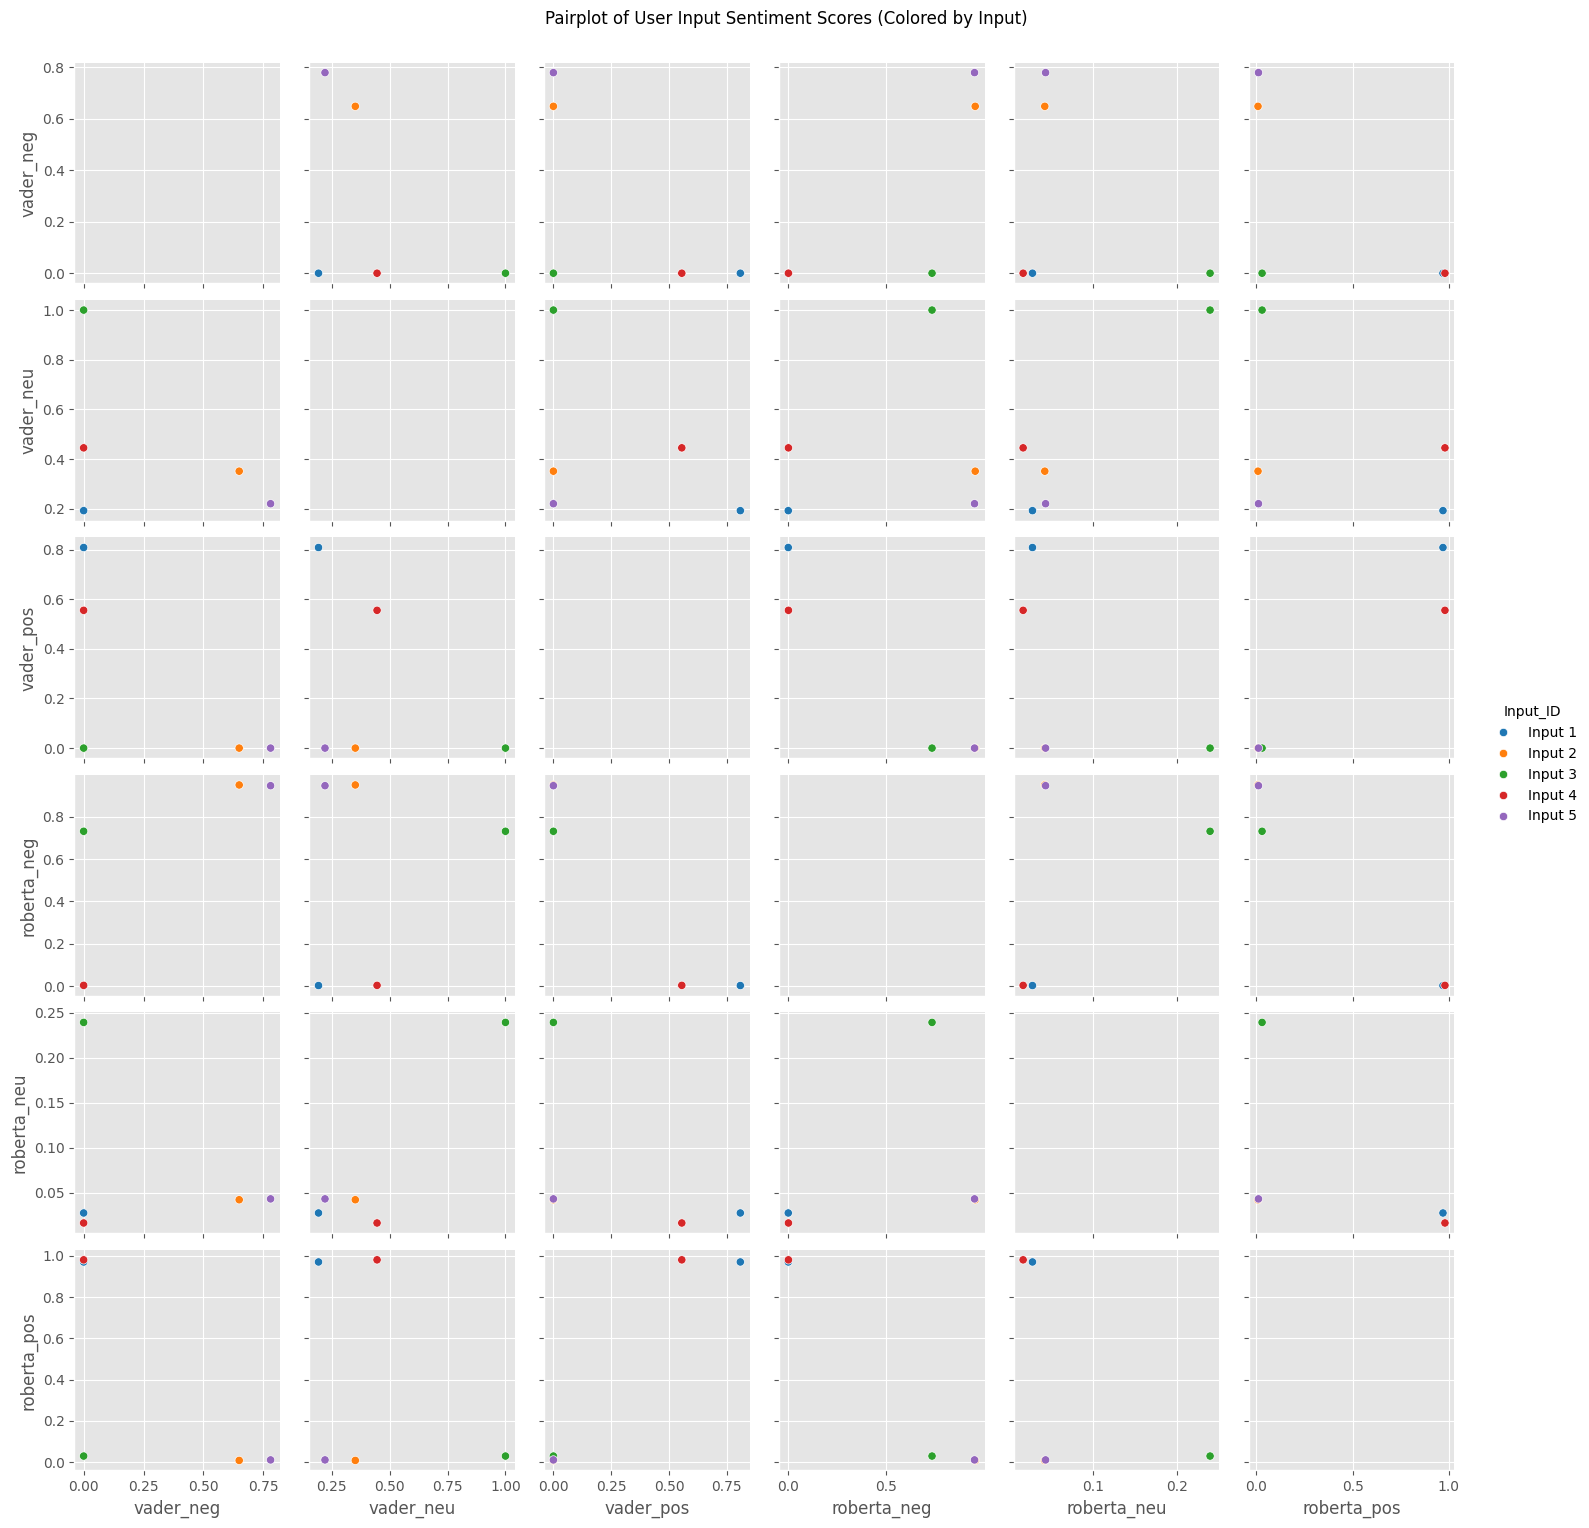

In [ ]:
if not user_scores_df.empty:
    sns.pairplot(user_scores_df,
                 vars=['vader_neg', 'vader_neu', 'vader_pos',
                       'roberta_neg', 'roberta_neu', 'roberta_pos'],
                 hue='Input_ID', # Use the new Input_ID column for coloring
                 palette='tab10') # Use a distinct color palette
    plt.suptitle('Pairplot of User Input Sentiment Scores (Colored by Input)', y=1.02)
    plt.show()
else:
    print("Cannot create a pairplot: No sentiment data available from user inputs.")

In [ ]:
def analyze_multiple_texts_and_plot(texts_string):
    all_user_scores_list = []
    input_counter = 0
    texts = texts_string.strip().split('\n')

    if not texts_string.strip():
        return pd.DataFrame(), None, "Please enter some text for analysis."

    for text_input in texts:
        if not text_input.strip():
            continue

        input_counter += 1

        # VADER sentiment analysis
        vader_result = sia.polarity_scores(text_input)
        vader_compound = vader_result['compound']
        vader_user_rename = {f"vader_{k}": v for k, v in vader_result.items()}

        # Determine VADER sentiment emoji and label
        if vader_compound >= 0.05:
            vader_sentiment_label = "Positive 😊"
        elif vader_compound <= -0.05:
            vader_sentiment_label = "Negative 😠"
        else:
            vader_sentiment_label = "Neutral 😐"

        # RoBERTa sentiment analysis
        roberta_result = polarity_scores_roberta(text_input)
        roberta_neg = roberta_result['roberta_neg']
        roberta_neu = roberta_result['roberta_neu']
        roberta_pos = roberta_result['roberta_pos']

        # Determine RoBERTa sentiment emoji and label
        if roberta_pos > roberta_neg and roberta_pos > roberta_neu:
            roberta_sentiment_label = "Positive 😊"
        elif roberta_neg > roberta_pos and roberta_neg > roberta_neu:
            roberta_sentiment_label = "Negative 😠"
        else:
            roberta_sentiment_label = "Neutral 😐"

        # Combine scores and store, including the original text, identifier, and emoji labels
        combined_scores = {
            "Input_ID": f"Input {input_counter}",
            "Original_Text": text_input,
            "VADER_Sentiment_Emoji": vader_sentiment_label,
            "RoBERTa_Sentiment_Emoji": roberta_sentiment_label,
            **vader_user_rename,
            **roberta_result # Note: roberta_result already has 'roberta_' prefix
        }
        all_user_scores_list.append(combined_scores)

    if not all_user_scores_list:
        return pd.DataFrame(), None, "No valid input provided for analysis."

    user_scores_df = pd.DataFrame(all_user_scores_list)

    # Generate pairplot
    fig = plt.figure(figsize=(15, 15))
    sns.pairplot(user_scores_df,
                 vars=['vader_neg', 'vader_neu', 'vader_pos',
                       'roberta_neg', 'roberta_neu', 'roberta_pos'],
                 hue='Input_ID',
                 palette='tab10')
    plt.suptitle('Pairplot of User Input Sentiment Scores (Colored by Input)', y=1.02)

    return user_scores_df, fig, "Analysis complete. See DataFrame and Pairplot below."
iface_multi = gr.Interface(
    fn=analyze_multiple_texts_and_plot,
    inputs=gr.Textbox(lines=10, label="Enter multiple texts (one per line)"),
    outputs=[
        gr.Dataframe(label="Sentiment Scores DataFrame"),
        gr.Plot(label="Sentiment Pairplot"),
        gr.Textbox(label="Status/Messages")
    ],
    title="Multiple Texts Sentiment Analysis with Pairplot",
    description="Enter multiple sentences or phrases (one per line) to analyze their sentiments and visualize relationships between scores."
)
print("Launching Multiple Texts Sentiment Analysis Interface...")
iface_multi.launch(debug=True, share=True)

Launching Multiple Texts Sentiment Analysis Interface...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://0ef25742b69b894928.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
